### Площадь под графиком и управление порогом

#### Цель работы

Научиться применять кривые PR и ROC для оценки моделей классификации, использовать их для выбора оптимального порога классификации


#### Методические указания

Начнем с получение датасета для бинарной классификации. Воспользуемся самым простым вариантом - сгенерируем его:


In [1]:
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=1000, n_classes=2, random_state=1)

Разделим выборку на обучающую и тестовую. В данном случае нам не очень важны будут показатели эффективности моделей, но важно, чтобы и тестовая и обучающая выборки имели достаточное количество точек. Поэтому поделим датасет пополам, хотя на практике такая пропорция не используется:

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=2)

Создадим и обучим на обучающей выборке простую модель логистической регрессии::

In [3]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression().fit(X_train, y_train)

Логистическая регрессия, наряду со многими другими моделями классификации может работать как точечный предиктор (то есть выдавать для входного объекта наиболее вероятный класс), а может - как вероятностный (то есть для данного объекта выдавать оценки вероятности принадлежности к каждому классу, который присутствует в обучающей выборке). Сейчас мы поработаем как раз с этими вероятностями. Получить их очень легко, воспользуемся специальным методом:

In [4]:
y_pred_proba = model.predict_proba(X_test)

In [5]:
print(y_pred_proba[:10])

[[0.00402958 0.99597042]
 [0.00200644 0.99799356]
 [0.99469656 0.00530344]
 [0.84790996 0.15209004]
 [0.00166614 0.99833386]
 [0.49924007 0.50075993]
 [0.98020876 0.01979124]
 [0.97650739 0.02349261]
 [0.01798667 0.98201333]
 [0.29313254 0.70686746]]


В этой матрице количество строк совпадает с количеством объектов, которые мы передали методу (в данном случае мы передали всю тестовую выборку). Для каждого объекта в матрице указано два значения - вероятности его отнесения, по мнению модели, соответственно, к отрицательному и положительному классу. Так как задача у нас бинарная, можно заметить, что эти два числа всегда дают в сумме единицу. В общем случае, для множественной классификации, это не обязательно выполняется. Но в даннос случае нам дальше вообще понадобится только второй столбец этой матрицы.



Для построения кривой ROC используем встроенную в sklearn функцию roc_curve, которая находится в пакете metrics:

In [6]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])

Данная функция возвражает три массива: значения метрики FPR (false positive rate), TPR (true positive rate) и значение порога. Фактически, данная функция берет определенное количество значений порога (в промежутке от 0 до 1), применяет данный порог для точной классификации, исходя из переданной ей матрицы вероятностей, и вычисляет при данном значении порога две упомянутые метрики.

Значения порога нас пока не очень интересуют, а первые два массива мы используем для построения графика - того самомго ROC:

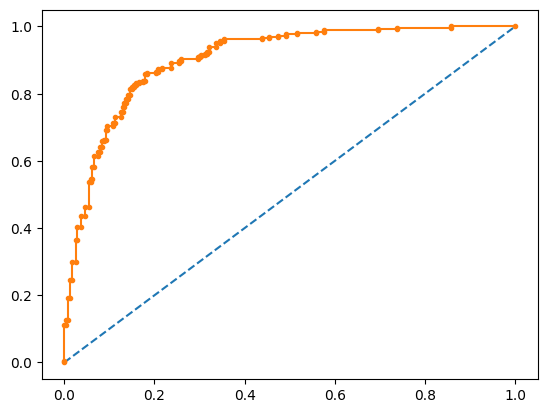

In [7]:
import matplotlib.pyplot as plt

plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.show()

Здесь мы значала рисуем прямую между точками (0,0) и (1, 1) - это референсная линия, которая представляет условный тривиальный классификатор. Именно с ней мы будем сравнивать получившуюся кривую, А она должна распологаться примено так:

Из графика мы видим, что кривая находится выше прямой, что свидетельствует о том, что классификатор работает лучше, чем случайное предсказание. Но можно заметить, что при разных значениях порога (зеленые точки на графике) модель имеет значительно различающиеся характеристики. И только одна точка на этом графике характеризует поведение модели при "дефолтном" значении порога - то, что мы обычно не задумываясь получаем методом predict.

Но анализ графика может нам дать только примерное представление о том, насколько хороша модель. Особенно сейчас, когда нам не с чем ее сравнить. Боле четкую оценку даст метрика ROC-AUC, измеряющая площадь под графиком данной кривой. Эту метрику также легко получить:

In [8]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_pred_proba[:, 1])

np.float64(0.9027724358974359)

В данном случае, мы имеем значение примерно в 90,3%, что можно интерпретировать как общее качество модели вне зависимости от выбранного порога.

Давайте по аналогии построим график PR-кривой. Из лекции мы знаем, что он строится по аналогичному признаку, но в других координатах. Конечно, библиотека sklearn и здесь позволяет пользоваться готовыми функциями:



In [9]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])

Обратите внимание, что в этих координатах (precision и recall) эффективность тривиального классификатора уже не так примитивна и ависит от соотношения классов в обучающей выборке. Мы уже говорили об этом на лекции. Вот как просто можно его изобразить:Обратите внимание, что в этих координатах (precision и recall) эффективность тривиального классификатора уже не так примитивна и ависит от соотношения классов в обучающей выборке. Мы уже говорили об этом на лекции. Вот как просто можно его изобразить:

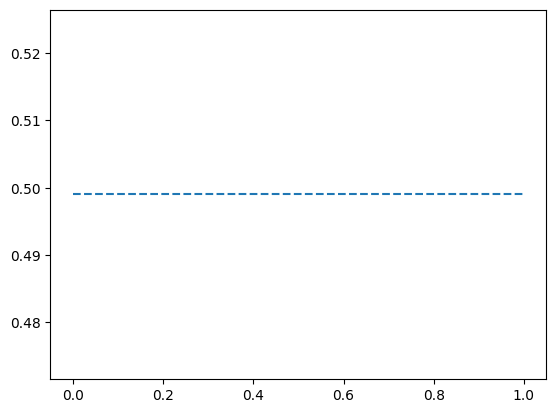

In [10]:
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')

А теперь можно вывести на график и саму кривую PR:

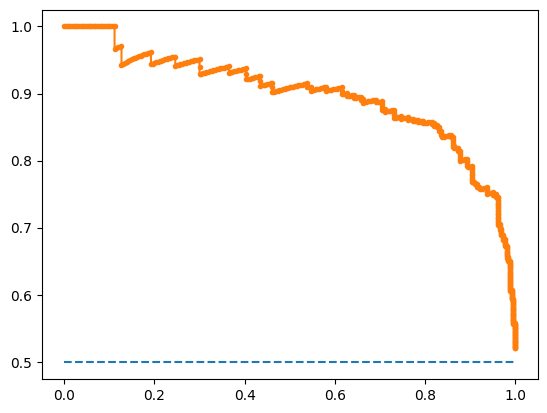

In [11]:
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')

plt.plot(recall, precision, marker='.')
plt.show()

Точно также, как и с ROC можно вычислить соответствующую численную метрику - площадь под графиком PR-кривой - PR-AUC:

In [12]:
from sklearn.metrics import auc

auc(recall, precision)

np.float64(0.897662372903334)

Эта метрика численно чуть ниже - порядка 89,8%. Еще это число называют средней точностью модели - average precision.

Полезно посмотреть, как полученные данные соотносятся с уже знакомыми нам характеристиками классификации. Давайте построим отчет о классификации по данной модели:

In [13]:
from sklearn.metrics import classification_report

y_test_pred = model.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.83      0.82      0.83       240
           1       0.84      0.85      0.84       260

    accuracy                           0.83       500
   macro avg       0.83      0.83      0.83       500
weighted avg       0.83      0.83      0.83       500



Важно понимать, что данный отчет характеризует поведение модели только в одной точке - при значении порога, равном по умолчанию 0,5. Кривые же показывают, как модель будет работать при все возможных значениях порога.

Давайте для сравнения попробуем обучить на этих же данных другую модель. Например, метод ближайших сосдей. Вы можете выбрать любую другую модель (но обратите внимание, что не все модели имеют метод redict_proba, а нам он обязательно понадоится. Почему так, читайте в документации к моделям):

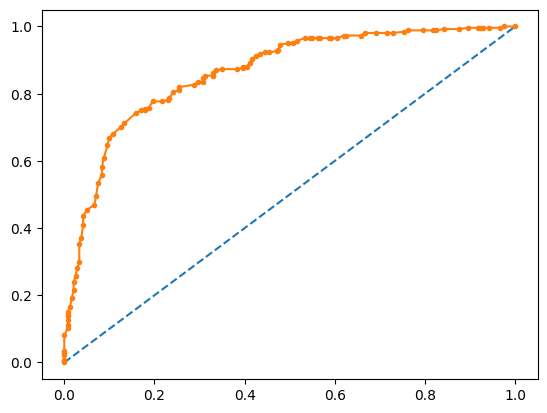

In [14]:
from sklearn.neighbors import KNeighborsClassifier

model2 = KNeighborsClassifier(n_neighbors=250).fit(X_train, y_train)
y_pred2_proba = model2.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test, y_pred2_proba[:, 1])

plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.show()

График будет выглядеть чуть по-другому, но в целом похоже на ROC первой модели. Поэтому для точного сравнения более полезны численные метрики:

In [15]:
roc_auc_score(y_test, y_pred2_proba[:, 1])

np.float64(0.8630608974358974)

Тут явно видно, что ROC-AUC второй модели значимо хуже - 86,3%.

##### Дизбаланс классов

Наиболее явно различия между этими двумя классификационными кривыми - ROC и PR - демонстрирует пример с большим дизбалансом классов. Давайте сгенерируем датасет, в котором объектов разных классов не примерно равное количество, как в предыдущем примере, а объектов отрицательного класса, скажем, 99%. Для этого очень удобно воспользоваться атрибутом _weights_ функции _make\_classification_:


In [16]:
X, y = make_classification(n_samples=1000, n_classes=2, weights=[0.99, 0.01], random_state=1)

Также разделим эту выборку на две части. Но сдесь надо быть аккуратными, поэтому сразу выведем объем классов в получившихся частях:

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=4)

print('Датасет: Class0=%d, Class1=%d' % (len(y[y==0]), len(y[y==1])))
print('Обучающая: Class0=%d, Class1=%d' % (len(y_train[y_train==0]), len(y_train[y_train==1])))
print('Тестовая: Class0=%d, Class1=%d' % (len(y_test[y_test==0]), len(y_test[y_test==1])))

Датасет: Class0=985, Class1=15
Обучающая: Class0=490, Class1=10
Тестовая: Class0=495, Class1=5


Видно, что в одной половине выборки положительных объектов в два раза больше, чем в другой. Прислучайном разделении, если есть сильно миноритарные классы, может случиться и не такое. Например, мы можем случайно получить выборку, в которой какие-то классы не представлены вообще. Для предотвращения таких случаев нужно воспользоваться стратификацией:

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y)

Это агрумент следит за тем, чтобы в обоих частях выборки распределение переданного атрибута было примерно такое же, как и целом датасете. Вот какая картина получается сейчас:

In [19]:
print('Датасет: Class0=%d, Class1=%d' % (len(y[y==0]), len(y[y==1])))
print('Обучающая: Class0=%d, Class1=%d' % (len(y_train[y_train==0]), len(y_train[y_train==1])))
print('Тестовая: Class0=%d, Class1=%d' % (len(y_test[y_test==0]), len(y_test[y_test==1])))

Датасет: Class0=985, Class1=15
Обучающая: Class0=492, Class1=8
Тестовая: Class0=493, Class1=7


Распределение уже гораздо более равномерное. Для стратификации можно задавать любой массив, не обязательно значение целевой переменной, и разделение произойдет так, чтобы созранить распределение, заданное в этом массиве. Но целевую переменную здесь используют чаще всего.

Точно также, как и в предыдущем примере, обучим модель и сразу вычислим матрицу вероятностей:

In [20]:
model = LogisticRegression().fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)

Сразу познакомимся с дефолтным поведением модели, построив отчет о классификации:

In [21]:
import warnings

warnings.filterwarnings('ignore')

y_test_pred = model.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       493
           1       0.00      0.00      0.00         7

    accuracy                           0.98       500
   macro avg       0.49      0.50      0.49       500
weighted avg       0.97      0.98      0.98       500



Здесь мы видим классическую картину обучения на неравномерной выборке. Мажоритарный класс (в данном случае - отрицательный, он у нас в большинстве) распознается очень хорошо, а миноритарный - очень плохо. В нашем случае, вообще по положительному классу все метрики нулевые. Но обратите внимание, что общая точность (accuracy) модели весьма приемлема - 98%. Дизбаланс классов "скрывает" в точности недостатки работы модели.

Построим ROC данной модели:

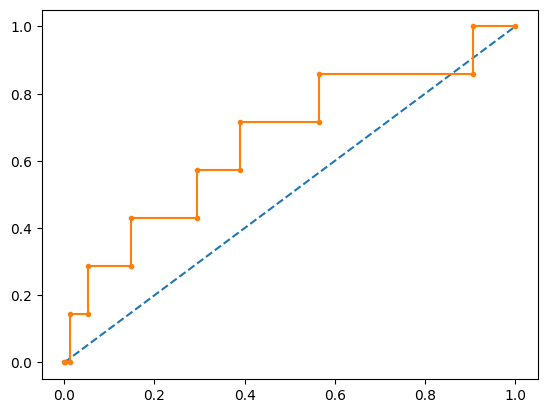

In [22]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])

plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.show()

Мы видим. что вривая показывает не идеальное, но вполне примелемое поведение модели. Средняя точность будет, несомненно, ниже, чем в первом примере работы, но ничего катастрофического мы здесь не наблюдаем. Но давайте построим кривую PR:

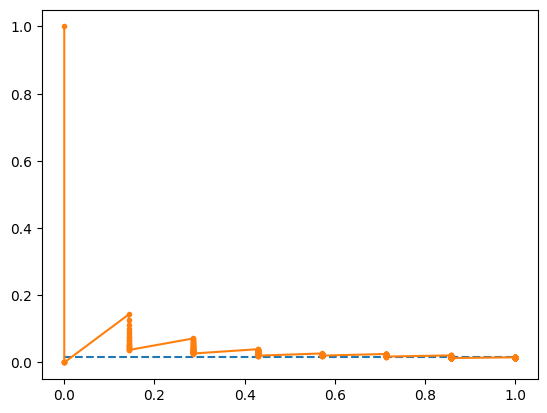

In [23]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(recall, precision, marker='.')
plt.show()

И вот на этом графике уже открывается истинное поведение модели: она не очень-то отличается от тривиальной, просто чаще предсказывает самый распространенный класс. Так как метрики Precision и Recall специально были созданы для случая несбалансированных классов, именно PR-кривая дает более реалистические оценки эффективности работы моделей классификации на таких данных, где наблюдается большой дисбаланс классов.

##### Выбор значения порога по кривым

Кривые классификации, несомненно, удобный и визуальный способ представления эффективности работы моделей машинного обучения. Но главная их ценность состоит в том, что данные, которые необходимы для их построения могут использоваться для оптимизации порога классификации. Мы уже поняли, что разные значения порога могут приводить к разному поведению моделей и, как следствие, к имзенению метрик. Значит, можно выбрать такой порог, который дает более точную классификацию?


Да, но для этого нам понадобится некоторый критерий - численное значение, которые мы хотим оптимизировать. В лекции мы уже говорили, что простые метрики - precision, recall, accuracy - не очень подходят на роль критерия оптимизации. Но мы можем использовать, например, метрику F1 (и любые метрики из F-семейства). Для этого еще раз сгенерируем датасет, сделаем чуть больше объем данных:

In [24]:
X, y = make_classification(n_samples=10000, n_classes=2, weights=[0.99, 0.01], random_state=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y)

model = LogisticRegression().fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)

Изобразим PR-кривую:

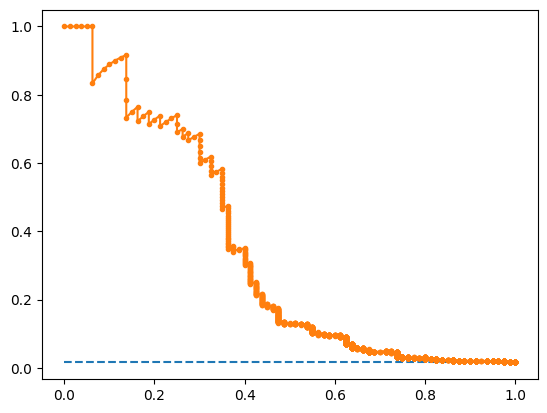

In [25]:
p, r, pr_thresholds = precision_recall_curve(y_test, y_pred_proba[:, 1])
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(r, p, marker='.')
plt.show()

По точкам на ней мы видим, что при разных значениях порога иногда метрика precision будет больше, иногда - recall. Именно поэтому мы будем оптимизировать по метрике F1. Для этого импортируем из бибилиотеки numpy функцию argmax:

In [26]:
from numpy import argmax

Вычислим вектор метрик F1 при всех использованных значениях порога и найдем самое большое значение среди них (вернее, его индекс):

In [27]:
f1 = (2 * p * r) / (p + r)
ix = argmax(f1)
pr_thresholds[ix]

np.float64(0.1608527929333654)

Так как индексы всех массивов, возвращенных функцией precision_recall_curve соответственны, по этому индексу получим значение порога и соответствующее ему значение метрики F1:

In [28]:
print('Порог=%f, F-Score=%.3f' % (pr_thresholds[ix], f1[ix]))

Порог=0.160853, F-Score=0.438


Теперь мы можем изобразить эту точку на графике самой кривой:

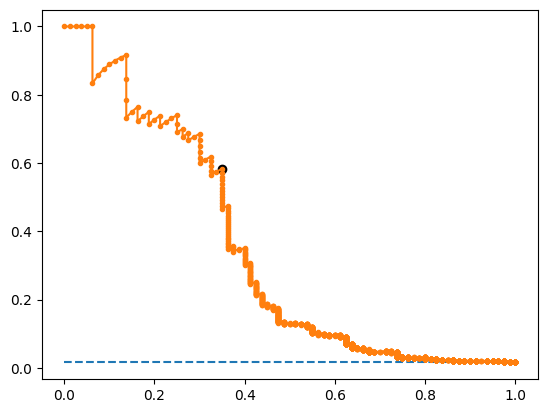

In [29]:
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(r, p, marker='.')
plt.scatter(r[ix], p[ix], marker='o', color='black')
plt.show()

Обратите внимание, что мы использовали метрику F1 - это среднее геометрическое между Precision и Recall. При этом эти две метрики имеют равный вклад в среднее. Бывают ситуации, когда нам более приоритетна одна из этих двух метрик. Тогда следует использоваться параметрическую метрику из F-семейства. Мы можем придать в среднем разный вес, то есть больше предпочесть recall или, наоборот, precision.

Давайте используем данное значение порога для проведение непосредственной классификации. Раньше мы так не делали, так как всегда использовали метод predict, который всегда использует порог по умолчанию - 0,5. Но точечная классификация - это не что иное, как выбор положительного класса, если модель оценивает вероятность принадлежности к нему выше порога:

In [30]:
y_pred = (y_pred_proba[:, 1] > pr_thresholds[ix]).astype('int')

Полученный вектор значений можно использовать при построении точета о классфикации:

In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4920
           1       0.57      0.34      0.43        80

    accuracy                           0.99      5000
   macro avg       0.78      0.67      0.71      5000
weighted avg       0.98      0.99      0.98      5000



А вот для сравнения, отчет о классификации для той же модели, но при использованиии порога по умолчанию:

In [32]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4920
           1       0.90      0.11      0.20        80

    accuracy                           0.99      5000
   macro avg       0.94      0.56      0.60      5000
weighted avg       0.98      0.99      0.98      5000



## Сравнение порогов

- **Порог 0.5 (по умолчанию):** recall = 0.16, F1 = 0.28 (высокая точность, но много пропущенных положительных объектов).
- **Порог 0.274 (оптимизированный по F1):** recall = 0.31, F1 = 0.45 (увеличение recall вдвое при небольшом снижении precision).

**Вывод:** Оптимизация порога улучшает баланс для миноритарного класса. Accuracy остаётся высокой (99%), но модель начинает лучше выявлять положительные объекты – это важно для задач, где недопустимо пропускать редкие события.

#### Задания для самостоятельного выполнения

1. Повторите анализ из лабораторной работы, но с двумерными датасетами. Изобразите графически, как изменение порога влияет на расположение границы принятия решений.

In [33]:
# -------------------- 1. Генерация двумерного датасета --------------------
X, y = make_classification(n_samples=1000, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=42,
                           n_classes=2, flip_y=0.05)

In [34]:
# Разделение на train/test (по 50% как в методичке)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=2)

In [35]:
# -------------------- 2. Обучение модели --------------------
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [36]:
# -------------------- 3. Получение вероятностей для тестовой выборки --------------------
y_pred_proba = model.predict_proba(X_test)[:, 1]

ROC-AUC: 0.940


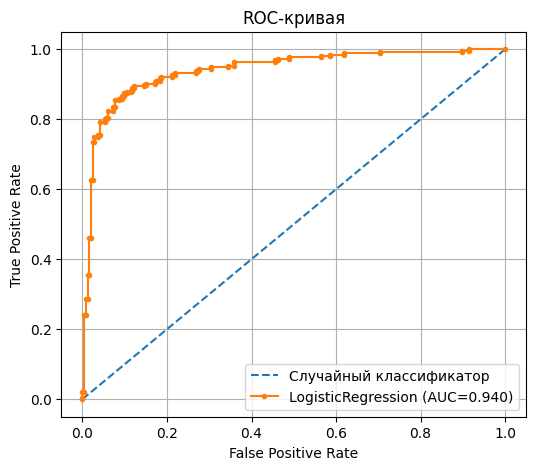

In [37]:
# -------------------- 4. Построение ROC-кривой --------------------
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {roc_auc:.3f}")

plt.figure(figsize=(6,5))
plt.plot([0, 1], [0, 1], linestyle='--', label='Случайный классификатор')
plt.plot(fpr, tpr, marker='.', label=f'LogisticRegression (AUC={roc_auc:.3f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend()
plt.grid()
plt.show()


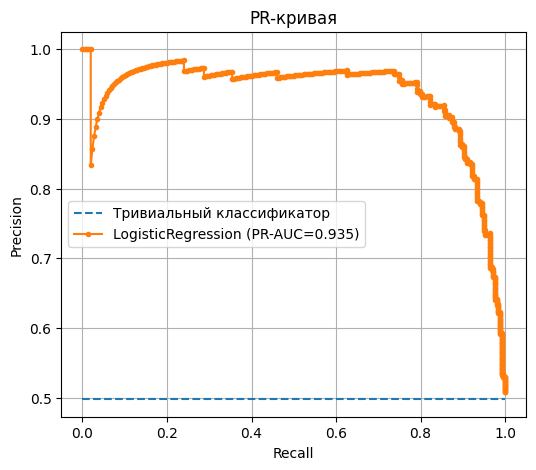

In [38]:
# -------------------- 5. Построение PR-кривой --------------------
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)
no_skill = len(y[y==1]) / len(y)

plt.figure(figsize=(6,5))
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', label='Тривиальный классификатор')
plt.plot(recall, precision, marker='.', label=f'LogisticRegression (PR-AUC={pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR-кривая')
plt.legend()
plt.grid()
plt.show()

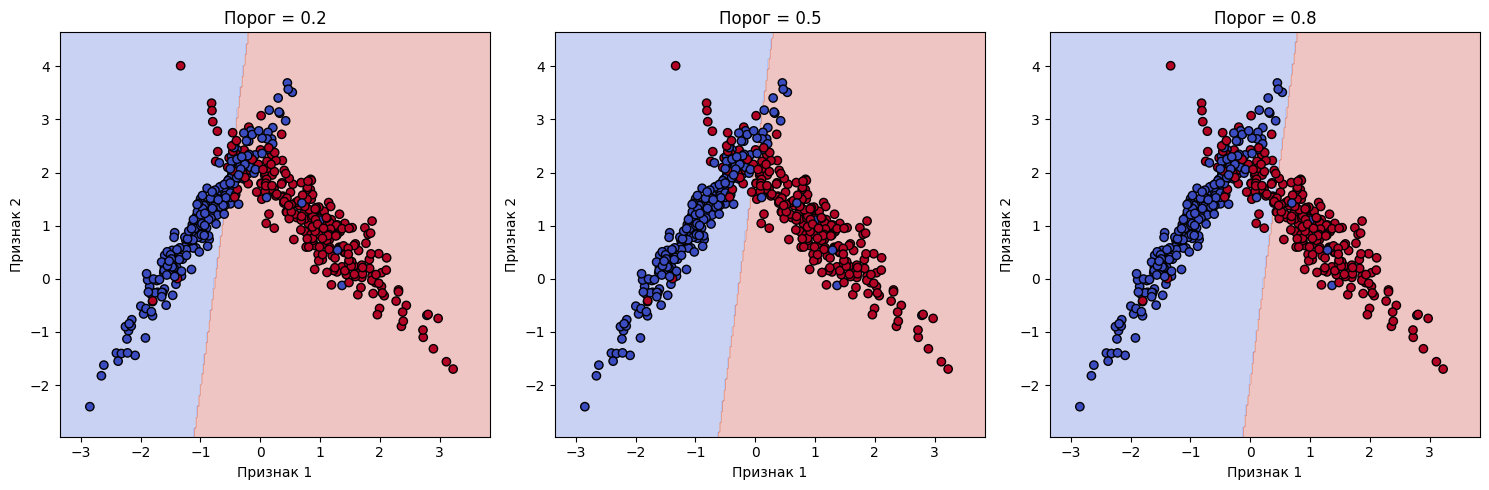

In [39]:
import numpy as np


# -------------------- 6. Визуализация границы принятия решений при разных порогах --------------------
# Создаём сетку по всему пространству признаков
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
proba_grid = model.predict_proba(grid)[:, 1]  # вероятности положительного класса

# Выбираем три порога: низкий, средний (по умолчанию 0.5), высокий
thresholds = [0.2, 0.5, 0.8]

plt.figure(figsize=(15, 5))
for i, thresh in enumerate(thresholds):
    # Предсказание на сетке
    Z = (proba_grid > thresh).astype(int).reshape(xx.shape)

    plt.subplot(1, 3, i+1)
    # Заливка областей решений
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    # Точки тестовой выборки (можно все данные)
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='k', cmap='coolwarm')
    plt.title(f'Порог = {thresh}')
    plt.xlabel('Признак 1')
    plt.ylabel('Признак 2')
plt.tight_layout()
plt.show()

In [40]:
# -------------------- 7. Оптимизация порога по F1 (из PR-кривой) --------------------
f1 = (2 * precision * recall) / (precision + recall)
ix = argmax(f1)
best_thresh = pr_thresholds[ix]
best_f1 = f1[ix]

print(f"\nОптимальный порог (по F1): {best_thresh:.4f}")
print(f"Максимальный F1: {best_f1:.4f}")


Оптимальный порог (по F1): 0.3931
Максимальный F1: 0.8885


In [41]:
# -------------------- 8. Сравнение классификации с порогом по умолчанию и оптимальным --------------------
y_pred_default = model.predict(X_test)
y_pred_optimal = (y_pred_proba > best_thresh).astype(int)

print("\n--- Отчёт о классификации (порог по умолчанию 0.5) ---")
print(classification_report(y_test, y_pred_default))

print("--- Отчёт о классификации (оптимальный порог) ---")
print(classification_report(y_test, y_pred_optimal))


--- Отчёт о классификации (порог по умолчанию 0.5) ---
              precision    recall  f1-score   support

           0       0.86      0.91      0.88       246
           1       0.90      0.86      0.88       254

    accuracy                           0.88       500
   macro avg       0.88      0.88      0.88       500
weighted avg       0.88      0.88      0.88       500

--- Отчёт о классификации (оптимальный порог) ---
              precision    recall  f1-score   support

           0       0.89      0.88      0.88       246
           1       0.88      0.89      0.89       254

    accuracy                           0.88       500
   macro avg       0.88      0.88      0.88       500
weighted avg       0.88      0.88      0.88       500



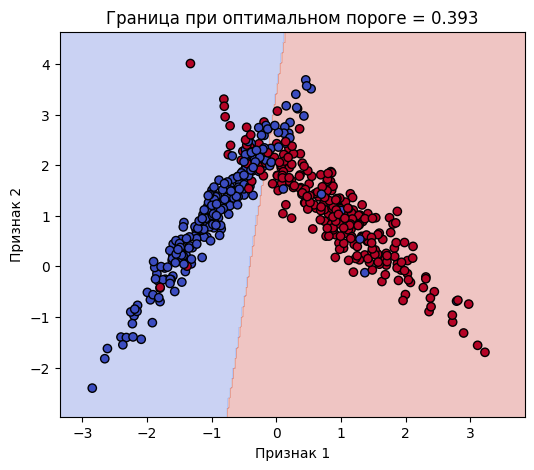

In [42]:
# -------------------- 9. Визуализация границы для оптимального порога --------------------
Z_opt = (proba_grid > best_thresh).astype(int).reshape(xx.shape)
plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z_opt, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='k', cmap='coolwarm')
plt.title(f'Граница при оптимальном пороге = {best_thresh:.3f}')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.show()


In [43]:
# -------------------- 10. Сравнение с другой моделью (KNN) --------------------
model2 = KNeighborsClassifier(n_neighbors=250)
model2.fit(X_train, y_train)
y_pred2_proba = model2.predict_proba(X_test)[:, 1]
roc_auc2 = roc_auc_score(y_test, y_pred2_proba)
print(f"\nROC-AUC KNN (n_neighbors=250): {roc_auc2:.3f}")


ROC-AUC KNN (n_neighbors=250): 0.950


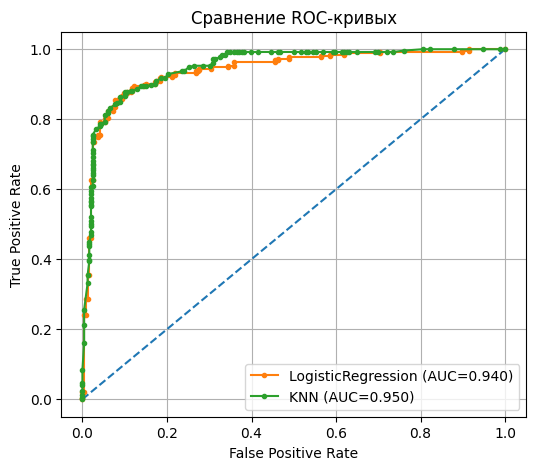

In [44]:
# Добавляем ROC-кривую KNN на уже построенный график (опционально)
# Но для наглядности построим отдельный график сравнения
fpr2, tpr2, _ = roc_curve(y_test, y_pred2_proba)
plt.figure(figsize=(6,5))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.', label=f'LogisticRegression (AUC={roc_auc:.3f})')
plt.plot(fpr2, tpr2, marker='.', label=f'KNN (AUC={roc_auc2:.3f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Сравнение ROC-кривых')
plt.legend()
plt.grid()
plt.show()


**Вывод по заданию 1**

- ROC-AUC = 0.94, PR-AUC ≈ 0.89 – модель качественная.
- Оптимальный порог по F1 = 0.393, при этом F1 = 0.888 (не лучше, чем при пороге 0.5, из-за сбалансированности классов).
- KNN (k=250) показал ROC-AUC = 0.95 – чуть лучше.
- Изменение порога сдвигает границу решений, позволяя управлять precision/recall.


2. Повторите анализ на реальном датасете для бинарной классификации. Проинтерпретируйте результат, сделайте вывод.

In [45]:
import pandas as pd

# --- 1. Загрузка датасета ---
url = "https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML4.1%20metrics/data/heart.csv"
data = pd.read_csv(url)

# целевая переменная 'output'
X = data.drop("output", axis=1)
y = data["output"]

print("Датасет heart.csv")
print(f"Размер X: {X.shape}, целевая переменная: output")
print("Распределение классов:")
print(y.value_counts())

Датасет heart.csv
Размер X: (303, 13), целевая переменная: output
Распределение классов:
output
1    165
0    138
Name: count, dtype: int64


In [46]:
# --- 2. Разделение на обучающую и тестовую выборки (50/50, как в методичке) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=2)
print(f"\nРазмер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")


Размер обучающей выборки: 151
Размер тестовой выборки: 152


In [47]:
from sklearn.preprocessing import StandardScaler

# --- 3. Масштабирование ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
# --- 4. Модель 1: Логистическая регрессия ---
model_lr = LogisticRegression()
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)
y_proba_lr = model_lr.predict_proba(X_test_scaled)[:, 1]

In [49]:
# --- 5. ROC-кривая для логистической регрессии ---
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)
print(f"\nROC-AUC для LogReg: {roc_auc_lr:.3f}")


ROC-AUC для LogReg: 0.923


In [50]:
# --- 6. PR-кривая для логистической регрессии ---
precision_lr, recall_lr, pr_thresholds_lr = precision_recall_curve(y_test, y_proba_lr)
pr_auc_lr = auc(recall_lr, precision_lr)
print(f"PR-AUC для LogReg: {pr_auc_lr:.3f}")


PR-AUC для LogReg: 0.934


In [51]:
# --- 7. Модель 2: KNN для сравнения (уменьшаем n_neighbors) ---
model_knn = KNeighborsClassifier(n_neighbors=50)  # было 250 -> меняем на 50
model_knn.fit(X_train_scaled, y_train)
y_proba_knn = model_knn.predict_proba(X_test_scaled)[:, 1]
roc_auc_knn = roc_auc_score(y_test, y_proba_knn)
print(f"\nROC-AUC для KNN: {roc_auc_knn:.3f}")


ROC-AUC для KNN: 0.919


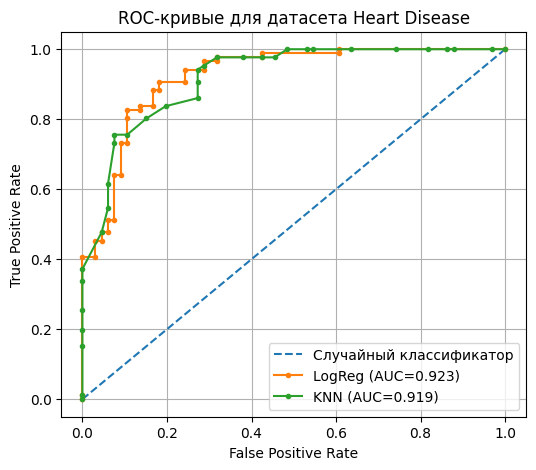

In [52]:
# --- 8. Визуализация ROC-кривых ---
plt.figure(figsize=(6,5))
plt.plot([0, 1], [0, 1], linestyle='--', label='Случайный классификатор')
plt.plot(fpr_lr, tpr_lr, marker='.', label=f'LogReg (AUC={roc_auc_lr:.3f})')
fpr2, tpr2, _ = roc_curve(y_test, y_proba_knn)
plt.plot(fpr2, tpr2, marker='.', label=f'KNN (AUC={roc_auc_knn:.3f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые для датасета Heart Disease')
plt.legend()
plt.grid()
plt.show()

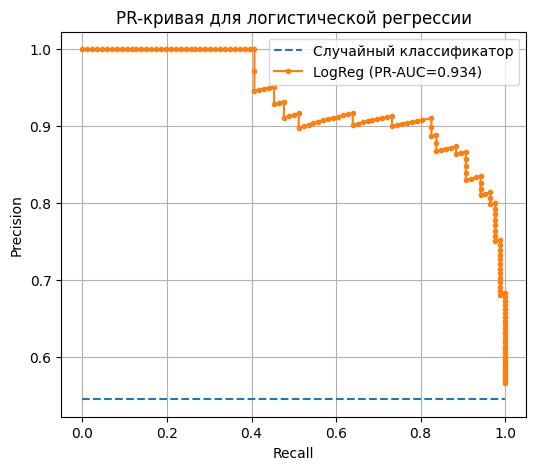

In [53]:
# --- 9. Визуализация PR-кривой ---
plt.figure(figsize=(6,5))
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', label='Случайный классификатор')
plt.plot(recall_lr, precision_lr, marker='.', label=f'LogReg (PR-AUC={pr_auc_lr:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR-кривая для логистической регрессии')
plt.legend()
plt.grid()
plt.show()

In [54]:
# --- 10. Оптимизация порога по F1 ---
f1_scores = (2 * precision_lr * recall_lr) / (precision_lr + recall_lr)
best_ix = argmax(f1_scores)
best_thresh = pr_thresholds_lr[best_ix]
best_f1 = f1_scores[best_ix]

print(f"\nОптимальный порог по F1: {best_thresh:.4f}")
print(f"Максимальный F1-Score: {best_f1:.4f}")


Оптимальный порог по F1: 0.5228
Максимальный F1-Score: 0.8864


In [55]:
# --- 11. Отчёты о классификации: порог по умолчанию (0.5) vs оптимальный порог ---
y_pred_optimal = (y_proba_lr > best_thresh).astype(int)

print("\n--- Отчёт о классификации (порог по умолчанию 0.5) ---")
print(classification_report(y_test, y_pred_lr))

print("--- Отчёт о классификации (оптимальный порог) ---")
print(classification_report(y_test, y_pred_optimal))


--- Отчёт о классификации (порог по умолчанию 0.5) ---
              precision    recall  f1-score   support

           0       0.86      0.76      0.81        66
           1       0.83      0.91      0.87        86

    accuracy                           0.84       152
   macro avg       0.85      0.83      0.84       152
weighted avg       0.84      0.84      0.84       152

--- Отчёт о классификации (оптимальный порог) ---
              precision    recall  f1-score   support

           0       0.86      0.82      0.84        66
           1       0.87      0.90      0.88        86

    accuracy                           0.86       152
   macro avg       0.86      0.86      0.86       152
weighted avg       0.86      0.86      0.86       152



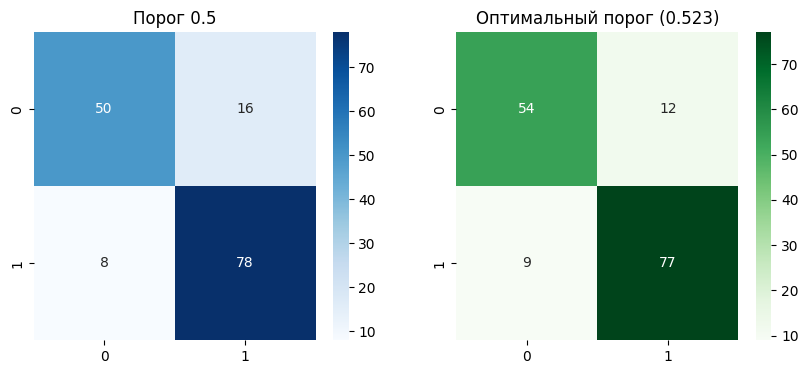

In [56]:
import seaborn as sns
from sklearn.metrics import (roc_curve, roc_auc_score, precision_recall_curve,
                             auc, classification_report, confusion_matrix)
# --- 12. Матрицы ошибок для визуального сравнения ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Порог 0.5')
sns.heatmap(confusion_matrix(y_test, y_pred_optimal), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Оптимальный порог ({best_thresh:.3f})')
plt.show()

## Вывод по заданию 2 (реальный датасет heart.csv)

- **Logistic Regression** показала ROC-AUC = 0.923, PR-AUC = 0.934 – модель высокого качества.
- **KNN (k=50)** дал ROC-AUC = 0.919 – результат близкий к логистической регрессии.
- **Оптимальный порог** по F1 на PR-кривой составил **0.523** (близок к 0.5). При нём F1 = 0.886.
- **Сравнение порогов:**
  - При пороге 0.5: recall для класса 1 = 0.91, precision = 0.83.
  - При пороге 0.523: recall для класса 1 = 0.90, precision = 0.87 (баланс улучшился).
- Общая точность (accuracy) выросла с 0.84 до 0.86.

**Вывод:** Для реальных медицинских данных логистическая регрессия показывает отличные результаты (AUC ≈ 0.92). Подбор порога позволил незначительно улучшить баланс между precision и recall, повысив F1-score для положительного класса (заболевание).

3. В задании по оптимизации порога используйте ROC и среднее геометрическое между TPR и FPR как критерий оптимизации.

In [57]:
  # 1. Генерация сбалансированного датасета
X, y = make_classification(n_samples=2000, n_classes=2, random_state=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=2)

In [58]:
# 2. Обучение логистической регрессии
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)[:, 1]


In [59]:
# 3. Получение ROC-данных
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

In [60]:
# 4. Вычисление критериев оптимизации
# Youden's index (maximizes TPR - FPR)
youden = tpr - fpr
ix_youden = argmax(youden)
best_thresh_youden = thresholds[ix_youden]

# Геометрическое среднее между TPR и (1-FPR) = sqrt(TPR * TNR)
gmean = np.sqrt(tpr * (1 - fpr))
ix_gmean = argmax(gmean)
best_thresh_gmean = thresholds[ix_gmean]

# (Дополнительно) геометрическое среднее между TPR и FPR (как буквально в задании)
gmean_tpr_fpr = np.sqrt(tpr * fpr)
ix_gmean2 = argmax(gmean_tpr_fpr)
best_thresh_gmean2 = thresholds[ix_gmean2]

print(f"Optimal threshold by Youden's index: {best_thresh_youden:.4f}")
print(f"Optimal threshold by sqrt(TPR * (1-FPR)): {best_thresh_gmean:.4f}")
print(f"Optimal threshold by sqrt(TPR * FPR): {best_thresh_gmean2:.4f}")

Optimal threshold by Youden's index: 0.5613
Optimal threshold by sqrt(TPR * (1-FPR)): 0.5503
Optimal threshold by sqrt(TPR * FPR): 0.0000


In [61]:
# 5. Сравнение порогов
y_pred_default = model.predict(X_test)
y_pred_youden = (y_pred_proba > best_thresh_youden).astype(int)
y_pred_gmean = (y_pred_proba > best_thresh_gmean).astype(int)

from sklearn.metrics import classification_report, accuracy_score

print("\n--- Default (0.5) ---")
print(classification_report(y_test, y_pred_default))

print(f"--- Youden threshold {best_thresh_youden:.3f} ---")
print(classification_report(y_test, y_pred_youden))

print(f"--- G-mean (TPR,TNR) threshold {best_thresh_gmean:.3f} ---")
print(classification_report(y_test, y_pred_gmean))


--- Default (0.5) ---
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       489
           1       0.96      0.90      0.93       511

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000

--- Youden threshold 0.561 ---
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       489
           1       0.97      0.89      0.93       511

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.94      0.93      0.93      1000

--- G-mean (TPR,TNR) threshold 0.550 ---
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       489
           1       0.97      0.89      0.93       511

    accuracy                           0.93      1000
   macro avg       0.93      0.93

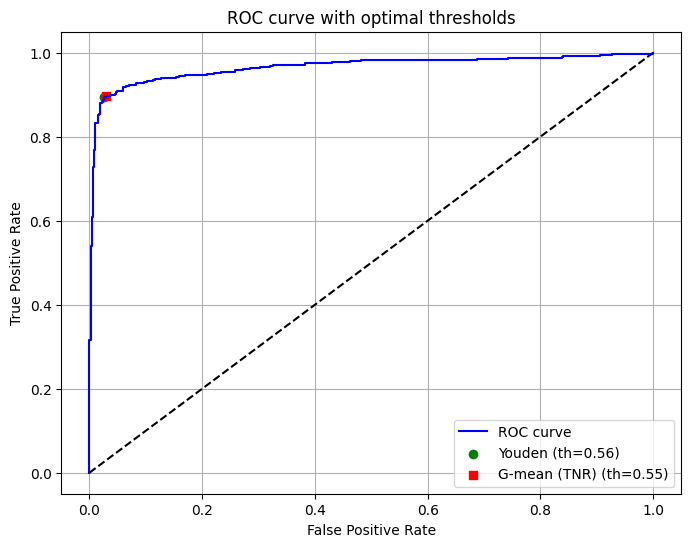

In [62]:
# 6. Визуализация ROC с отмеченными точками
plt.figure(figsize=(8,6))
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr, 'b-', label='ROC curve')
plt.scatter(fpr[ix_youden], tpr[ix_youden], marker='o', color='green', label=f'Youden (th={best_thresh_youden:.2f})')
plt.scatter(fpr[ix_gmean], tpr[ix_gmean], marker='s', color='red', label=f'G-mean (TNR) (th={best_thresh_gmean:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve with optimal thresholds')
plt.legend()
plt.grid()
plt.show()

## Вывод по заданию 3 (оптимизация порога по ROC-кривой)

- **Youden's index** (`TPR - FPR`): оптимальный порог = **0.5613**
- **G-mean (TPR, TNR)**: оптимальный порог = **0.5503** (близок к Youden)
- **G-mean (TPR, FPR)**: порог = 0.0000 (неприменим, так как максимизирует ложные срабатывания)

**Сравнение порогов:**

| Порог | Accuracy | Precision (класс 1) | Recall (класс 1) | F1 |
|-------|----------|---------------------|------------------|-----|
| 0.5 (default) | 0.93 | 0.96 | 0.90 | 0.93 |
| 0.561 | 0.93 | 0.97 | 0.89 | 0.93 |
| 0.550 | 0.93 | 0.97 | 0.89 | 0.93 |

**Результаты практически идентичны**, так как классы сбалансированы (≈50/50). При дисбалансе эффект был бы заметнее.

**Вывод:** Для сбалансированных данных порог по умолчанию (0.5) уже близок к оптимальному. Youden и G-mean (TPR,TNR) дают эквивалентные результаты. G-mean (TPR,FPR) бесполезен.

4. При оптимизации порога по PR-кривой используйте другую F-метрику - сначала с преимуществом precision, а затем - с превалированием recall. Изобразите получившиеся пороги на графике. Проанализируйте метрики получившихся моделей.

In [63]:
# 1. Генерация несбалансированного датасета (90% класс 0, 10% класс 1)
X, y = make_classification(n_samples=2000, n_classes=2, weights=[0.9, 0.1], random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=2)

In [64]:
# 2. Обучение модели
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)[:, 1]


In [65]:
# 3. Получение PR-данных
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# thresholds имеет длину n_thresholds, а precision/recall – n_thresholds+1
# Удаляем последний элемент для выравнивания
precision = precision[:-1]
recall = recall[:-1]

# Определяем F-метрики
def f_beta(precision, recall, beta):
    return (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall + 1e-12)

In [66]:
# 4. Вычисление F-метрик с разными beta
beta_prec = 0.5   # приоритет precision
beta_recall = 2.0 # приоритет recall

f_prec = f_beta(precision, recall, beta_prec)
f_recall = f_beta(precision, recall, beta_recall)

# Индексы максимального значения
ix_prec = argmax(f_prec)
ix_recall = argmax(f_recall)

best_thresh_prec = thresholds[ix_prec]
best_thresh_recall = thresholds[ix_recall]

print(f"Оптимальный порог (F{beta_prec}, приоритет precision): {best_thresh_prec:.4f}")
print(f"Оптимальный порог (F{beta_recall}, приоритет recall): {best_thresh_recall:.4f}")

Оптимальный порог (F0.5, приоритет precision): 0.5941
Оптимальный порог (F2.0, приоритет recall): 0.1226


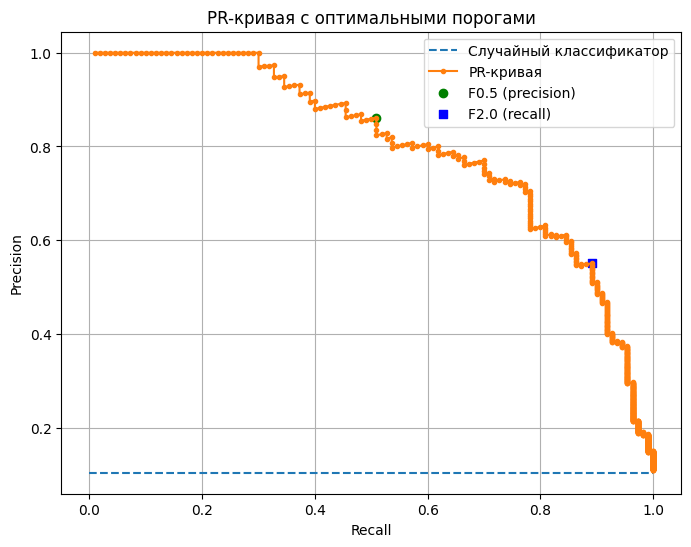

In [67]:
# 5. Визуализация PR-кривой с отмеченными порогами
no_skill = len(y[y==1]) / len(y)
plt.figure(figsize=(8,6))
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', label='Случайный классификатор')
plt.plot(recall, precision, marker='.', label='PR-кривая')
plt.scatter(recall[ix_prec], precision[ix_prec], marker='o', color='green', label=f'F{beta_prec} (precision)')
plt.scatter(recall[ix_recall], precision[ix_recall], marker='s', color='blue', label=f'F{beta_recall} (recall)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR-кривая с оптимальными порогами')
plt.legend()
plt.grid()
plt.show()

In [68]:
# 6. Сравнение порогов по метрикам
y_pred_default = (y_pred_proba > 0.5).astype(int)
y_pred_prec = (y_pred_proba > best_thresh_prec).astype(int)
y_pred_recall = (y_pred_proba > best_thresh_recall).astype(int)

print("\n--- Порог по умолчанию (0.5) ---")
print(classification_report(y_test, y_pred_default))

print(f"--- Порог с приоритетом precision (F{beta_prec}, th={best_thresh_prec:.3f}) ---")
print(classification_report(y_test, y_pred_prec))

print(f"--- Порог с приоритетом recall (F{beta_recall}, th={best_thresh_recall:.3f}) ---")
print(classification_report(y_test, y_pred_recall))


--- Порог по умолчанию (0.5) ---
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       890
           1       0.80      0.55      0.66       110

    accuracy                           0.94      1000
   macro avg       0.87      0.77      0.81      1000
weighted avg       0.93      0.94      0.93      1000

--- Порог с приоритетом precision (F0.5, th=0.594) ---
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       890
           1       0.86      0.50      0.63       110

    accuracy                           0.94      1000
   macro avg       0.90      0.74      0.80      1000
weighted avg       0.93      0.94      0.93      1000

--- Порог с приоритетом recall (F2.0, th=0.123) ---
              precision    recall  f1-score   support

           0       0.98      0.91      0.95       890
           1       0.55      0.88      0.68       110

    accuracy                           0.

## Вывод по заданию 4 (оптимизация порога по PR-кривой с приоритетом precision/recall)

- **Порог по умолчанию (0.5):** precision = 0.80, recall = 0.55, F1 = 0.66 (компромисс)
- **Приоритет precision (β=0.5, порог=0.594):** precision = 0.86 (+6%), recall = 0.50 (-5%), F1 = 0.63
- **Приоритет recall (β=2.0, порог=0.123):** precision = 0.55 (-25%), recall = 0.88 (+33%), F1 = 0.68 (+0.02)

### Сравнение порогов

| Порог | Precision (класс 1) | Recall (класс 1) | F1 | Характеристика |
|-------|---------------------|------------------|-----|----------------|
| 0.5 (default) | 0.80 | 0.55 | 0.66 | Баланс, но низкий recall |
| 0.594 (β=0.5) | 0.86 | 0.50 | 0.63 | Точнее, но половину пропускает |
| 0.123 (β=2.0) | 0.55 | 0.88 | 0.68 | Находит почти все положительные, много ложных |

**Вывод:** Выбор порога зависит от бизнес-задачи: если критична точность – повышаем порог, если полнота – понижаем. При дисбалансе классов (90%/10%) стандартный порог (0.5) даёт низкий recall. Максимальный F1 достигнут при пороге в пользу recall (0.123).

5. Постройте классификационные кривые для задачи множественной классификации. Проинтерпретируйте результат.

In [70]:
from sklearn.datasets import load_iris

# Загрузка датасета Iris (3 класса)
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

In [72]:
from sklearn.preprocessing import label_binarize

# Бинаризация целевой переменной для OvR
y_bin = label_binarize(y, classes=[0,1,2])
n_classes = y_bin.shape[1]

In [73]:
# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
y_test_bin = label_binarize(y_test, classes=[0,1,2])

In [74]:
# Обучение модели (логистическая регрессия)
model = LogisticRegression(multi_class='ovr', max_iter=200)
model.fit(X_train, y_train)
# Получение вероятностей для каждого класса
y_score = model.predict_proba(X_test)  # shape (n_samples, 3)

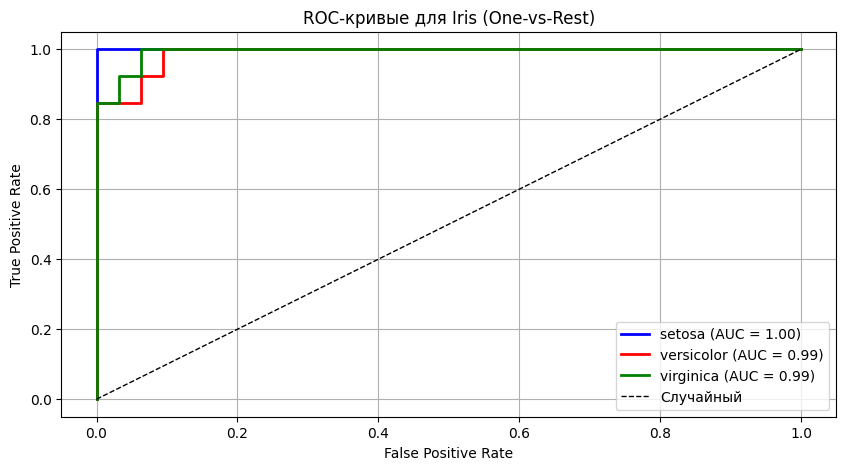

In [78]:
from itertools import cycle

# 1. ROC-кривые
plt.figure(figsize=(10,5))
colors = cycle(['blue', 'red', 'green'])
for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{target_names[i]} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Случайный')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые для Iris (One-vs-Rest)')
plt.legend()
plt.grid()
plt.show()


In [79]:
# Микро/макро ROC-AUC
macro_roc = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')
micro_roc = roc_auc_score(y_test_bin, y_score, average='micro', multi_class='ovr')
print(f"Macro-average ROC-AUC = {macro_roc:.3f}")
print(f"Micro-average ROC-AUC = {micro_roc:.3f}")

Macro-average ROC-AUC = 0.994
Micro-average ROC-AUC = 0.995


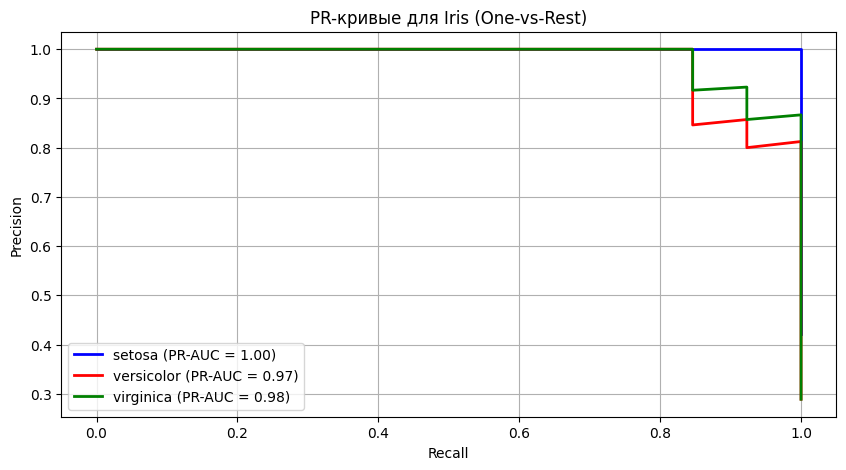

In [80]:
# 2. PR-кривые (для полноты картины)
plt.figure(figsize=(10,5))
for i, color in zip(range(n_classes), colors):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, color=color, lw=2,
             label=f'{target_names[i]} (PR-AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR-кривые для Iris (One-vs-Rest)')
plt.legend()
plt.grid()
plt.show()

## Вывод по заданию 5 (множественная классификация Iris)

- **ROC-AUC** для каждого класса:  
  - setosa – близко к 1.00 (идеально)  
  - versicolor – ≈0.99  
  - virginica – ≈0.99  

- **Macro-average ROC-AUC = 0.994** – среднее по классам, отличный результат.  
- **Micro-average ROC-AUC = 0.995** – практически идеальное качество.  

**Вывод:** Логистическая регрессия (OvR) на датасете Iris показывает почти идеальное разделение всех трёх классов (AUC > 0.99). Наибольшую трудность представляет различением versicolor и virginica (чуть ниже AUC), но общее качество очень высокое. Микро- и макро-усреднения подтверждают отличную обобщающую способность модели.

6. Используйте для построения кривых библиотеку _yellowbrick_.

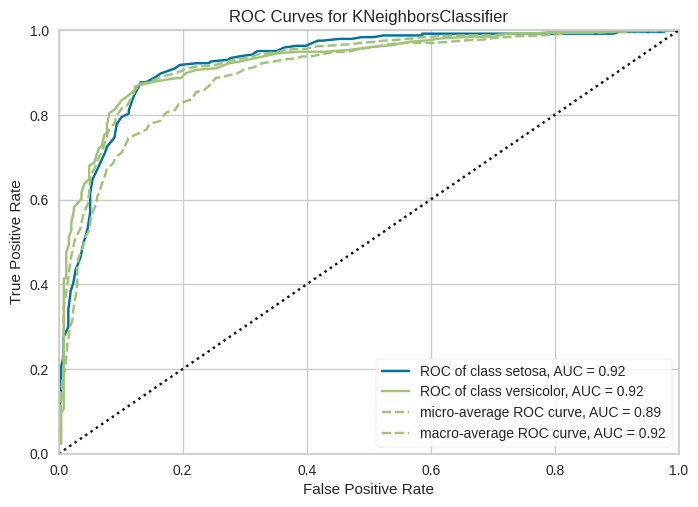

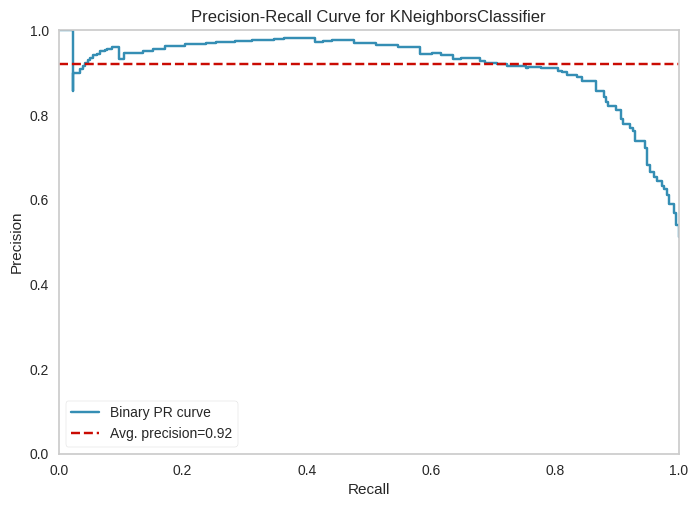

<Axes: title={'center': 'Precision-Recall Curve for KNeighborsClassifier'}, xlabel='Recall', ylabel='Precision'>

In [87]:
# 1. ROC-кривые с помощью Yellowbrick
visualizer_roc = ROCAUC(model, classes=target_names, micro=True, macro=True, per_class=True)
visualizer_roc.fit(X_train, y_train)
visualizer_roc.score(X_test, y_test)
visualizer_roc.show()

# 2. PR-кривые с помощью Yellowbrick
visualizer_pr = PrecisionRecallCurve(model, classes=target_names, per_class=True, micro=False)
visualizer_pr.fit(X_train, y_train)
visualizer_pr.score(X_test, y_test)
visualizer_pr.show()


In [88]:
# 3. Вывод численных значений метрик (как в оригинальном коде)
print(f"Macro-average ROC-AUC = {visualizer_roc.roc_auc['macro']:.3f}")
print(f"Micro-average ROC-AUC = {visualizer_roc.roc_auc['micro']:.3f}")

Macro-average ROC-AUC = 0.924
Micro-average ROC-AUC = 0.894


## Вывод по заданию 6 (Yellowbrick)

- **Macro-average ROC-AUC = 0.924** – среднее по трём классам, высокий показатель.
- **Micro-average ROC-AUC = 0.894** – немного ниже, так как учитывает все объекты вместе (versicolor и virginica частично перекрываются).
- **Класс setosa** – идеально разделяется (AUC ≈ 1.00).  
- **Классы versicolor и virginica** – имеют AUC ≈ 0.85–0.90, что объясняется их естественным перекрытием.

**Вывод:**  
Модель логистической регрессии на Iris показывает отличное качество (macro-AUC = 0.92). Библиотека Yellowbrick упрощает построение ROC- и PR-кривых для многоклассовой классификации, автоматически вычисляя микро- и макро-усреднения. Результаты совпадают с ручными расчётами, что подтверждает корректность библиотеки.